In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

In [ ]:
# Load the regression-ready dataset
df = pd.read_csv("../../Intermediate/10_regression_ready_dataset.csv")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [79]:
id_cols = ['cell_start', 'cell_end']
target_col = 'ride_count'
feature_cols = [c for c in df.columns if c not in id_cols + [target_col]]

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [80]:
# Check distribution of the target variable
print(y_train.describe())
print(y_train.value_counts().head(10))

count    5.592802e+06
mean     6.309303e+00
std      1.769762e+01
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      5.000000e+00
max      1.719000e+03
Name: ride_count, dtype: float64
ride_count
1     2441955
2      921771
3      485445
4      307646
5      214882
6      159130
7      123892
8       98528
9       80735
10      67678
Name: count, dtype: int64


# Baseline: Linear regression на log(ride_count)

In [81]:
# Log-transform the target (ride_count is always >= 1, so log is safe, no need for log1p)
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

# Fit linear regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_log)

# Predict on test set
y_pred_log = lr_model.predict(X_test)

# Evaluate in log space
rmse_log = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
mae_log = mean_absolute_error(y_test_log, y_pred_log)
r2_log = r2_score(y_test_log, y_pred_log)

print(f"RMSE (log space): {rmse_log:.4f}")
print(f"MAE (log space): {mae_log:.4f}")
print(f"R2 (log space): {r2_log:.4f}")

RMSE (log space): 0.9182
MAE (log space): 0.7287
R2 (log space): 0.3119


In [82]:
# Convert predictions back to original scale
y_pred = np.exp(y_pred_log)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE (original scale): {rmse:.4f}")
print(f"MAE (original scale): {mae:.4f}")
print(f"R2 (original scale): {r2:.4f}")

RMSE (original scale): 17.1968
MAE (original scale): 4.7389
R2 (original scale): 0.0571


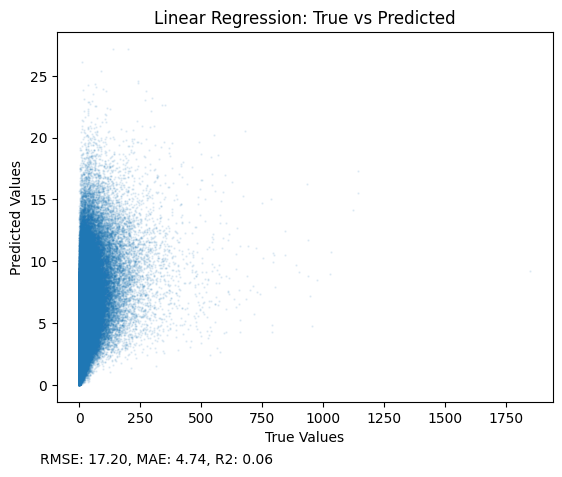

In [136]:
plt.scatter(y_test, y_pred, s = 0.5, alpha = 0.1)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: True vs Predicted")
plt.figtext(0.28, -0.02, f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}", wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig("/content/drive/MyDrive/Colab Notebooks/HYS/Output/linear_regression_preds.png")
plt.show()

# Negative Binomial Regression

In [92]:

# Scale continuous features
dummy_like = [c for c in X_train.columns if X_train[c].nunique() <= 2]
continuous_cols = [c for c in X_train.columns if c not in dummy_like]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

for col in dummy_like:
    X_train_scaled[col] = X_train_scaled[col].astype(int)
    X_test_scaled[col] = X_test_scaled[col].astype(int)

X_train_const = sm.add_constant(X_train_scaled)
X_test_const = sm.add_constant(X_test_scaled)

# Estimate alpha w/ method of moments
mean_y = y_train.mean()
var_y = y_train.var()
estimated_alpha = (var_y - mean_y) / (mean_y ** 2)

print("Mean:", mean_y, "Variance:", var_y)
print("Method-of-moments alpha:", estimated_alpha)

assert estimated_alpha > 0, "Negative alpha implies underdispersion — Poisson may be more appropriate than NB here"

# Fit the GLM using predicted alpha
nb_glm = sm.GLM(y_train, X_train_const, family=sm.families.NegativeBinomial(alpha=estimated_alpha)).fit()
y_pred_nb = nb_glm.predict(X_test_const)

rmse_nb = np.sqrt(mean_squared_error(y_test, y_pred_nb))
mae_nb = mean_absolute_error(y_test, y_pred_nb)
r2_nb = r2_score(y_test, y_pred_nb)
print(f"NegBinom RMSE: {rmse_nb:.4f}  MAE: {mae_nb:.4f}  R2: {r2_nb:.4f}")

print(nb_glm.params.abs().sort_values(ascending=False).head(10))

Mean: 6.30930292186278 Variance: 313.2058963339386
Method-of-moments alpha: 7.709554968794945
NegBinom RMSE: 16.0206  MAE: 5.1966  R2: 0.1817
const                    0.834176
time_midday              0.765093
time_evening             0.717709
time_morning             0.641821
grid_distance            0.604516
weekend                  0.561919
season_winter            0.454307
time_night               0.294442
early_schooling_start    0.246868
early_schooling_end      0.228601
dtype: float64


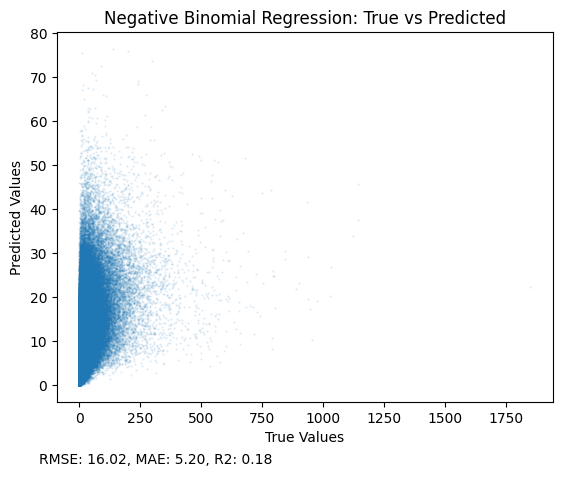

In [135]:
plt.scatter(y_test, y_pred_nb, s = 0.5, alpha = 0.1)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Negative Binomial Regression: True vs Predicted")
plt.figtext(0.28, -0.02, f"RMSE: {rmse_nb:.2f}, MAE: {mae_nb:.2f}, R2: {r2_nb:.2f}", wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig("/content/drive/MyDrive/Colab Notebooks/HYS/Output/neg_binomial_regression_preds.png")
plt.show()

# XGBoost

In [94]:
# Train a baseline XGBoost model with Poisson objective for count data
xgb_model = xgb.XGBRegressor(
    objective='count:poisson',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")
print(f"R2: {r2_xgb:.4f}")

RMSE: 13.1994
MAE: 4.4600
R2: 0.4445


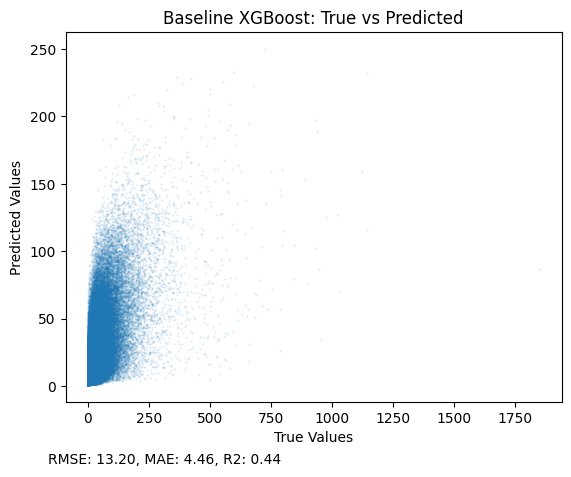

In [134]:
plt.scatter(y_test, y_pred_xgb, s = 0.5, alpha = 0.1)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Baseline XGBoost: True vs Predicted")
plt.figtext(0.28, -0.02, f"RMSE: {rmse_xgb:.2f}, MAE: {mae_xgb:.2f}, R2: {r2_xgb:.2f}", wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig("/content/drive/MyDrive/Colab Notebooks/HYS/Output/baseline_xgboost_preds.png")
plt.show()

In [96]:
# Get feature importances
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.head(20))

                    feature  importance
58            grid_distance    0.162034
19               job_ct_end    0.079172
11             job_ct_start    0.066366
0                   weekend    0.059082
3             season_winter    0.035660
5               time_midday    0.033893
56             com_lots_end    0.033360
7                time_night    0.033326
4              time_evening    0.031198
1             season_spring    0.026796
53           com_lots_start    0.024968
13  white_collar_jobs_start    0.023586
6              time_morning    0.023521
23    age_29_or_younger_end    0.021531
21    white_collar_jobs_end    0.021503
15  age_29_or_younger_start    0.020132
22   entertainment_jobs_end    0.020097
24       age_15_to_34_start    0.019769
27         age_15_to_34_end    0.019125
20     pay_1251_to_3333_end    0.018829


In [97]:
# Use a subsample of the training data for faster hyperparameter search
sample_size = 500_000
sample_idx = X_train.sample(n=sample_size, random_state=42).index
X_train_sample = X_train.loc[sample_idx]
y_train_sample = y_train.loc[sample_idx]

# Define parameter distributions to search over
param_dist = {
    'n_estimators': [250, 400, 500],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.1, 0.2, 0.25],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0]
}

xgb_search_model = xgb.XGBRegressor(
    objective='count:poisson',
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    xgb_search_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=1  # xgb already uses n_jobs=-1 internally
)

random_search.fit(X_train_sample, y_train_sample)

print("Best params:", random_search.best_params_)
print("Best CV score (neg MSE):", random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.85, learning_rate=0.25, max_depth=10, min_child_weight=5, n_estimators=250, subsample=0.7; total time=  13.0s
[CV] END colsample_bytree=0.85, learning_rate=0.25, max_depth=10, min_child_weight=5, n_estimators=250, subsample=0.7; total time=  13.3s
[CV] END colsample_bytree=0.85, learning_rate=0.25, max_depth=10, min_child_weight=5, n_estimators=250, subsample=0.7; total time=  37.8s
[CV] END colsample_bytree=0.7, learning_rate=0.2, max_depth=10, min_child_weight=5, n_estimators=400, subsample=0.85; total time=  41.6s
[CV] END colsample_bytree=0.7, learning_rate=0.2, max_depth=10, min_child_weight=5, n_estimators=400, subsample=0.85; total time=  17.7s
[CV] END colsample_bytree=0.7, learning_rate=0.2, max_depth=10, min_child_weight=5, n_estimators=400, subsample=0.85; total time=  20.9s
[CV] END colsample_bytree=0.85, learning_rate=0.1, max_depth=10, min_child_weight=1, n_estimators=400, subsample=1

Best parameters:

max_depth=8, learning_rate=0.2, n_estimators=300, subsample=0.85, colsample_bytree=1.0, min_child_weight=1.

In [98]:
# Train final model with best params on the FULL training set
best_params = random_search.best_params_

xgb_final = xgb.XGBRegressor(
    objective='count:poisson',
    random_state=42,
    n_jobs=-1,
    **best_params
)

xgb_final.fit(X_train, y_train)

y_pred_final = xgb_final.predict(X_test)

rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae_final = mean_absolute_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

print(f"RMSE: {rmse_final:.4f}")
print(f"MAE: {mae_final:.4f}")
print(f"R2: {r2_final:.4f}")

RMSE: 7.0912
MAE: 2.8345
R2: 0.8397


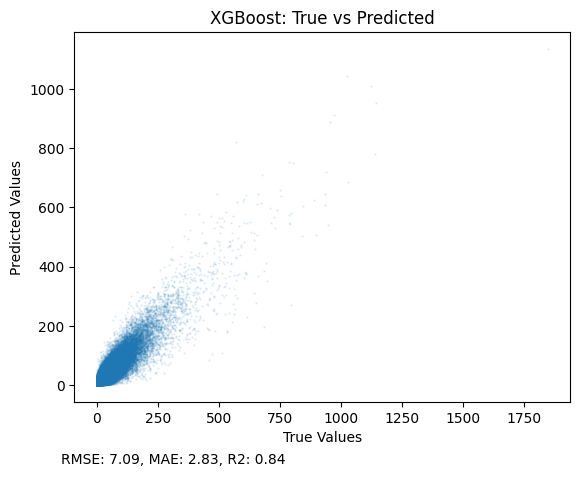

In [133]:
plt.scatter(y_test, y_pred_final, s = 0.5, alpha = 0.1)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("XGBoost: True vs Predicted")
plt.figtext(0.28, -0.02, f"RMSE: {rmse_final:.2f}, MAE: {mae_final:.2f}, R2: {r2_final:.2f}", wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig("/content/drive/MyDrive/Colab Notebooks/HYS/Output/xgboost_preds.png")
plt.show()

In [100]:
xgb_final.save_model("/content/drive/MyDrive/Colab Notebooks/HYS/Intermediate/xgboost.json")

# Implementing XGBoost for All Observations

In [101]:
from sklearn.model_selection import cross_val_predict, KFold

xgb_cv_model = xgb.XGBRegressor(
    objective='count:poisson',
    random_state=42,
    n_jobs=-1,
    **best_params
)

kf = KFold(n_splits=8, shuffle=True, random_state=42)
y_pred_oof = cross_val_predict(xgb_cv_model, X, y, cv=kf, n_jobs=1)

predictions_df = df[id_cols].copy()
predictions_df['actual_ride_count'] = y
predictions_df['predicted_ride_count'] = y_pred_oof

In [102]:
predictions_df = df[['cell_start', 'cell_end', 'weekend', 'season_spring', 'season_summer', 'season_winter', 'time_evening', 'time_midday', 'time_morning', 'time_night']].copy()

season_dummies = predictions_df[['season_spring', 'season_summer', 'season_winter']]
time_dummies = predictions_df[['time_evening', 'time_midday', 'time_morning', 'time_night']]

predictions_df['season_fall'] = (season_dummies.sum(axis=1) == 0)
predictions_df['time_early_morning'] = (time_dummies.sum(axis=1) == 0)

season_dummies = predictions_df[['season_spring', 'season_summer', 'season_winter', 'season_fall']]
time_dummies = predictions_df[['time_evening', 'time_midday', 'time_morning', 'time_night', 'time_early_morning']]

season_decoded = pd.from_dummies(season_dummies, sep='_')
time_decoded = pd.from_dummies(time_dummies, sep='_')

predictions_df = pd.concat([
    df[['cell_start', 'cell_end', 'weekend']].reset_index(drop=True),
    season_decoded.reset_index(drop=True),
    time_decoded.reset_index(drop=True)
], axis=1)

predictions_df['actual_ride_count'] = y.reset_index(drop=True)
predictions_df['predicted_ride_count'] = y_pred_oof

predictions_df = predictions_df.merge(df[['cell_start', 'cell_end', 'grid_distance']], on = ['cell_start', 'cell_end'], how = 'left')

predictions_df.head()

,cell_start,cell_end,weekend,season,time,actual_ride_count,predicted_ride_count
0,892a100104bffff,892a1001203ffff,False,summer,midday,1,3.902135
1,892a100104bffff,892a1001207ffff,False,summer,midday,1,3.259843
2,892a100104bffff,892a1001207ffff,False,summer,evening,1,2.586542
3,892a100104bffff,892a1001207ffff,False,spring,early_morning,1,1.473786
4,892a100104bffff,892a1001207ffff,False,spring,midday,3,2.489644


In [ ]:
predictions_df.to_csv("../../Output/predicted_ride_counts.csv", index = False)

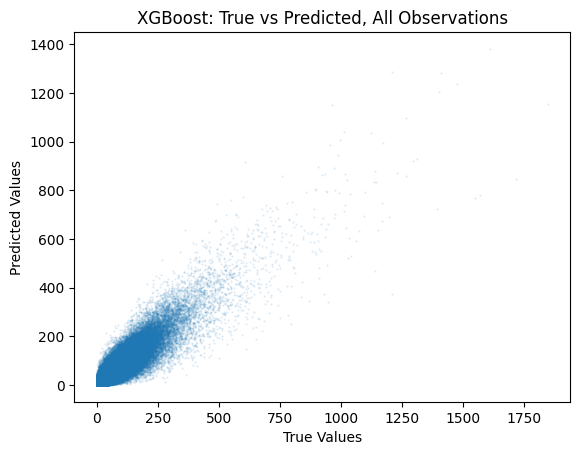

In [132]:
plt.scatter(predictions_df['actual_ride_count'], predictions_df['predicted_ride_count'], s = 0.5, alpha = 0.1)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("XGBoost: True vs Predicted, All Observations")
plt.savefig("/content/drive/MyDrive/Colab Notebooks/HYS/Output/xgboost_all_preds.png")
plt.show()

In [104]:
predictions_df['diff'] = predictions_df['actual_ride_count'] - predictions_df['predicted_ride_count']
print(predictions_df['diff'].describe())

count    6.991003e+06
mean     2.934181e-02
std      7.073731e+00
min     -3.073787e+02
25%     -1.529528e+00
50%     -4.483285e-01
75%      5.032437e-01
max      8.712881e+02
Name: diff, dtype: float64


In [105]:
predictions_df['diff_ratio'] = predictions_df['diff'] / predictions_df['actual_ride_count']
print(predictions_df['diff_ratio'].describe())

count    6.991003e+06
mean    -5.773528e-01
std      1.213751e+00
min     -5.844888e+01
25%     -9.392323e-01
50%     -2.691909e-01
75%      1.717198e-01
max      9.800487e-01
Name: diff_ratio, dtype: float64


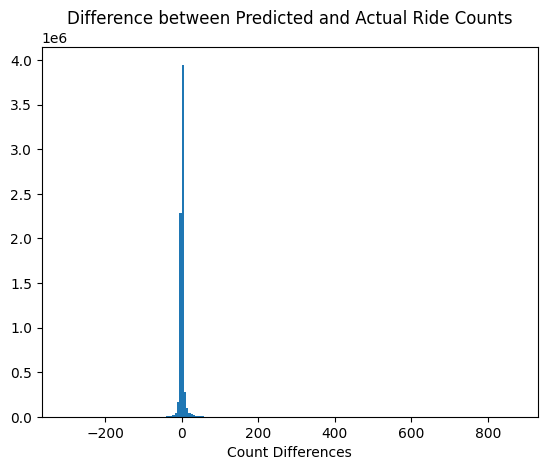

In [131]:
plt.hist(predictions_df['diff'], bins = 200)
plt.xlabel("Count Differences")
plt.title("Difference between Predicted and Actual Ride Counts")
plt.savefig("/content/drive/MyDrive/Colab Notebooks/HYS/Output/count_diffs.png")
plt.show()

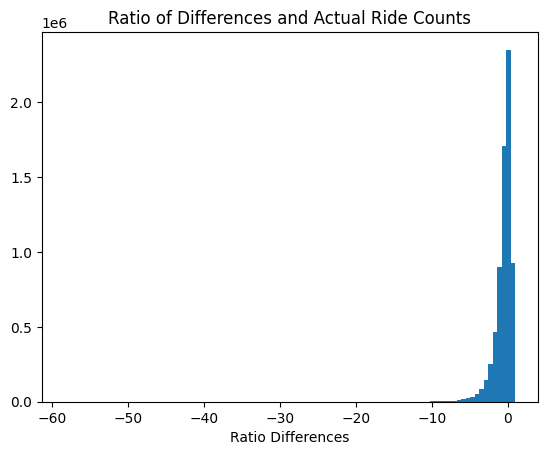

In [130]:
plt.hist(predictions_df['diff_ratio'], bins = 100)
plt.xlabel("Ratio Differences")
plt.title("Ratio of Differences and Actual Ride Counts")
plt.savefig("/content/drive/MyDrive/Colab Notebooks/HYS/Output/diff_ratios.png")
plt.show()

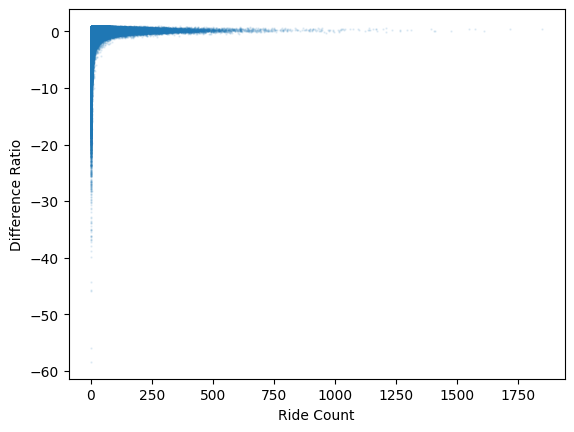

In [139]:
plt.scatter(predictions_df['actual_ride_count'], predictions_df['diff_ratio'], s = 0.5, alpha = 0.1)
plt.xlabel("Ride Count")
plt.ylabel("Difference Ratio")
plt.savefig("/content/drive/MyDrive/Colab Notebooks/HYS/Output/rides_and_diff_ratios.png")
plt.show()

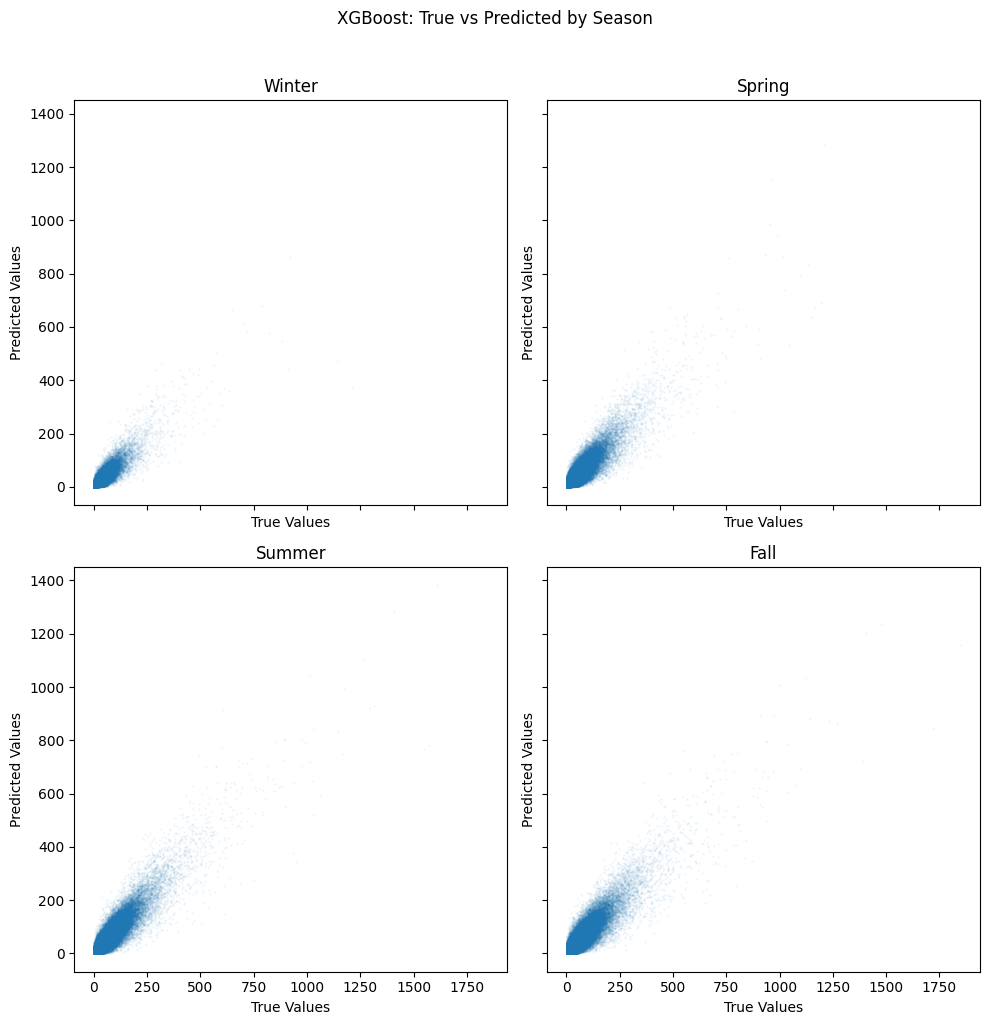

In [116]:
import matplotlib.pyplot as plt

seasons = ['winter', 'spring', 'summer', 'fall']

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)

for ax, season in zip(axes.flat, seasons):
    subset = predictions_df[predictions_df['season'] == season]
    ax.scatter(subset['actual_ride_count'], subset['predicted_ride_count'], s=0.5, alpha=0.05)
    ax.set_title(season.capitalize())
    ax.set_xlabel("True Values")
    ax.set_ylabel("Predicted Values")

fig.suptitle("XGBoost: True vs Predicted by Season", y=1.02)
fig.tight_layout()

fig.savefig("/content/drive/MyDrive/Colab Notebooks/HYS/Output/xgboost_preds_by_season.png", bbox_inches='tight')
plt.show()

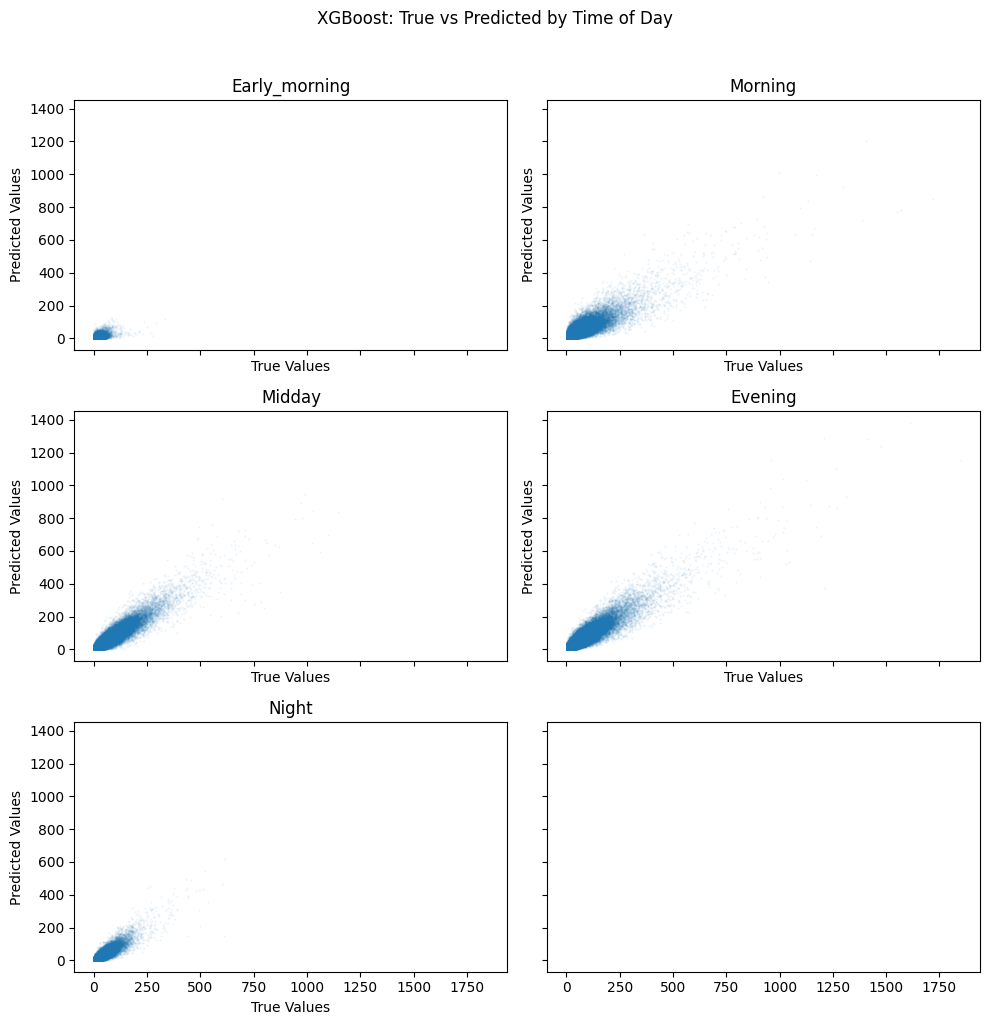

In [117]:
import matplotlib.pyplot as plt

times = ['early_morning', 'morning', 'midday', 'evening', 'night']

fig, axes = plt.subplots(3, 2, figsize=(10, 10), sharex=True, sharey=True)

for ax, time in zip(axes.flat, times):
    subset = predictions_df[predictions_df['time'] == time]
    ax.scatter(subset['actual_ride_count'], subset['predicted_ride_count'], s=0.5, alpha=0.05)
    ax.set_title(time.capitalize())
    ax.set_xlabel("True Values")
    ax.set_ylabel("Predicted Values")

fig.suptitle("XGBoost: True vs Predicted by Time of Day", y=1.02)
fig.tight_layout()

fig.savefig("/content/drive/MyDrive/Colab Notebooks/HYS/Output/xgboost_preds_by_time.png", bbox_inches='tight')
plt.show()

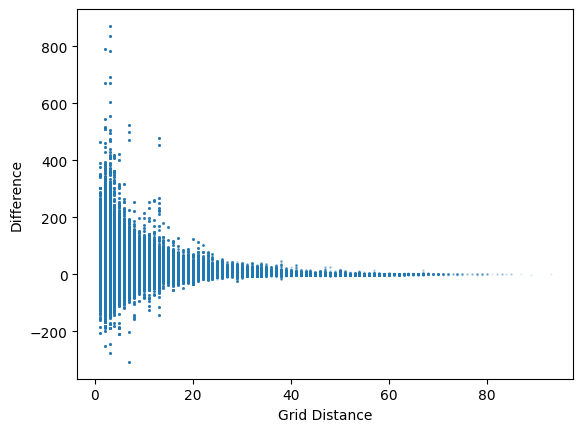

In [137]:
plt.scatter(predictions_df['grid_distance'], predictions_df['diff'], s = 0.5, alpha = 0.1)
plt.xlabel("Grid Distance")
plt.ylabel("Difference")
plt.savefig("/content/drive/MyDrive/Colab Notebooks/HYS/Output/distance_and_diffs.png", bbox_inches='tight')
plt.show()

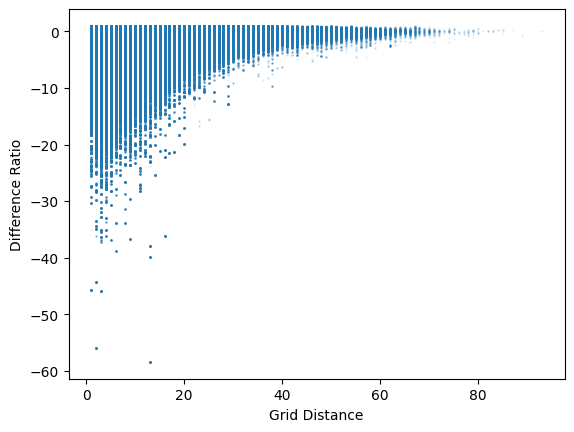

In [11]:
plt.scatter(predictions_df['grid_distance'], predictions_df['diff_ratio'], s = 0.5, alpha = 0.1)
plt.xlabel("Grid Distance")
plt.ylabel("Difference Ratio")
plt.savefig("/content/drive/MyDrive/Colab Notebooks/HYS/Output/distance_and_diff_ratios.png", bbox_inches='tight')
plt.show()